# Task 2 — Sentiment & Thematic Analysis
## All Banks: CBE · BOA · Dashen

This notebook:
1. Loads the cleaned reviews from Task 1
2. Runs DistilBERT sentiment analysis on every review
3. Extracts top keywords per bank using TF-IDF
4. Assigns each review to a business theme
5. Visualizes results and saves the enriched dataset


## 1. Imports & Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Local modules from src/
from src.sentiment import load_sentiment_pipeline, run_sentiment
from src.themes    import extract_top_keywords, assign_themes, theme_summary

# Paths
CLEAN_PATH  = "../data/raw/reviews_clean.csv"
OUTPUT_PATH = "../data/raw/reviews_analyzed.csv"
PLOTS_DIR   = "../plots"

os.makedirs(PLOTS_DIR, exist_ok=True)
print("Setup complete.")

c:\Users\hp\documents\10x\fintech-review-analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


## 2. Load Cleaned Data

Load `reviews_clean.csv` produced by Task 1.

In [2]:
df = pd.read_csv(CLEAN_PATH)

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nReviews per bank:")
print(df["bank"].value_counts().to_string())
df.head()

Shape  : (1208, 5)
Columns: ['review', 'rating', 'date', 'bank', 'source']

Reviews per bank:
bank
Dashen    423
BOA       410
CBE       375


,review,rating,date,bank,source
0,Good,5,2026-05-16,CBE,Google Play
1,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play
2,worst,1,2026-05-16,CBE,Google Play
3,this app very full,5,2026-05-15,CBE,Google Play
4,good apps,4,2026-05-15,CBE,Google Play


## 3. Sentiment Analysis with DistilBERT

### What DistilBERT is
DistilBERT is a smaller, faster version of BERT — a transformer model trained on
millions of sentences to understand natural language context.

Unlike simple rule-based tools, it reads the whole sentence before deciding.
For example:
- `"The app is not bad"` → POSITIVE (understands double negative)
- `"Fast transfers but terrible support"` → depends on which part dominates

### What the score means
- `sentiment_label = 'positive'`, `sentiment_score = 0.98` → very confident it is positive
- `sentiment_label = 'negative'`, `sentiment_score = 0.52` → barely negative — treat with caution

**Note:** The model downloads ~250MB on first run and caches locally after that.

In [3]:
# Load the model (downloads on first run, uses cache after)
pipe = load_sentiment_pipeline()

Loading DistilBERT model (downloads on first run)...


c:\Users\hp\documents\10x\fintech-review-analytics\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hp\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1277.84it/s]

Model loaded successfully.


In [4]:
# Run sentiment on all reviews
# batch_size=32 is a safe default — reduce to 16 if you run out of memory
df = run_sentiment(df, pipe, batch_size=32)

print(f"\nNew columns added: sentiment_label, sentiment_score")
df[["review", "bank", "sentiment_label", "sentiment_score"]].head(10)

Running sentiment on 1208 reviews (batch_size=32)...

Sentiment distribution (all banks):
  positive  :   640  (53.0%)
  negative  :   568  (47.0%)

New columns added: sentiment_label, sentiment_score


,review,bank,sentiment_label,sentiment_score
0,Good,CBE,positive,0.9998
1,🤙🏼🤙🏼,CBE,negative,0.6971
2,worst,CBE,negative,0.9998
3,this app very full,CBE,positive,0.9974
4,good apps,CBE,positive,0.9999
5,ok,CBE,positive,0.9998
6,this update got crazy i don't know what's goin...,CBE,negative,0.9995
7,thanks for you 😘,CBE,positive,0.9996
8,it's okay,CBE,positive,0.9998
9,It's not allowing me to transfer money.,CBE,negative,0.9969


### Sentiment breakdown per bank

Check positive vs negative proportions for each bank separately.

In [5]:
sentiment_by_bank = (
    df.groupby(["bank", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)

# Add percentage columns
for label in ["positive", "negative"]:
    if label in sentiment_by_bank.columns:
        total = sentiment_by_bank.sum(axis=1)
        sentiment_by_bank[f"{label}_pct"] = (sentiment_by_bank[label] / total * 100).round(1)

print(sentiment_by_bank.to_string())

sentiment_label  negative  positive  positive_pct  negative_pct
bank                                                           
BOA                   229       181          44.1          50.4
CBE                   161       214          57.1          37.3
Dashen                178       245          57.9          37.0


## 4. Visualization 1 — Sentiment Distribution (Stacked Bar)

This chart is your opening slide for the client. It immediately shows
which bank has the most dissatisfied users.

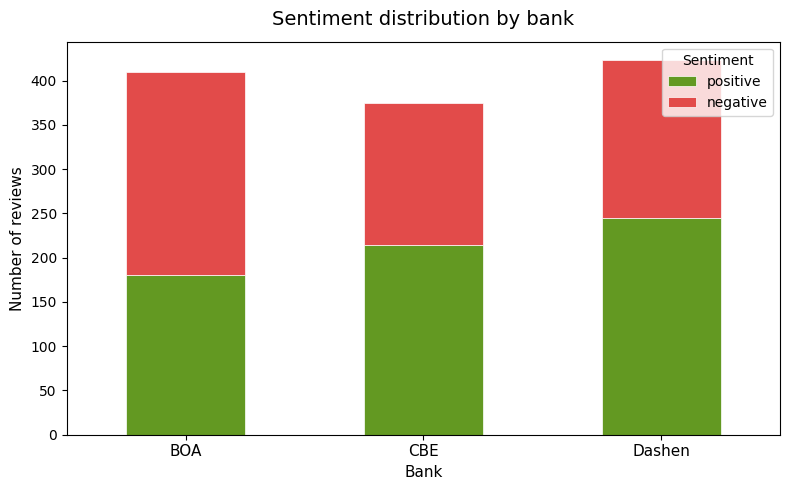

Saved → plots/sentiment_by_bank.png


In [6]:
counts = (
    df.groupby(["bank", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
    [["positive", "negative"]]   # consistent column order
)

fig, ax = plt.subplots(figsize=(8, 5))

counts.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color={"positive": "#639922", "negative": "#E24B4A"},
    edgecolor="white",
    linewidth=0.5,
)

ax.set_title("Sentiment distribution by bank", fontsize=14, pad=12)
ax.set_xlabel("Bank", fontsize=11)
ax.set_ylabel("Number of reviews", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.legend(title="Sentiment", fontsize=10)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/sentiment_by_bank.png", dpi=150)
plt.show()
print("Saved → plots/sentiment_by_bank.png")

## 5. Visualization 2 — Average Sentiment Score per Bank

The stacked bar shows counts. This chart shows the average confidence
score — a more nuanced view of how strongly users feel.

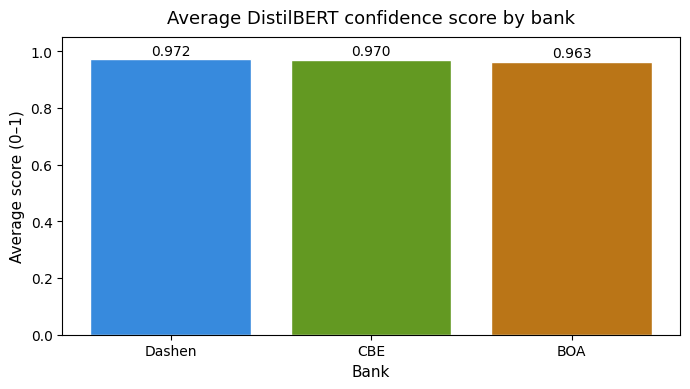

Saved → plots/avg_score_by_bank.png


In [7]:
avg_score = df.groupby("bank")["sentiment_score"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(avg_score.index, avg_score.values,
              color=["#378ADD", "#639922", "#BA7517"], edgecolor="white")

for bar, val in zip(bars, avg_score.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Average DistilBERT confidence score by bank", fontsize=13, pad=10)
ax.set_xlabel("Bank", fontsize=11)
ax.set_ylabel("Average score (0–1)", fontsize=11)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/avg_score_by_bank.png", dpi=150)
plt.show()
print("Saved → plots/avg_score_by_bank.png")

## 6. Keyword Extraction with TF-IDF

### What TF-IDF does
- **TF (Term Frequency):** how often a word appears in one review
- **IDF (Inverse Document Frequency):** penalizes words that appear in ALL reviews (like "app", "bank")
- **Result:** words that are distinctively common for ONE bank — these reveal what users talk about most

We use `ngram_range=(1,2)` to capture both single words (`"crash"`)
and two-word phrases (`"login error"`, `"transfer failed"`).

In [8]:
for bank in ["CBE", "BOA", "Dashen"]:
    print(f"\n{'='*40}")
    keywords = extract_top_keywords(df, bank_name=bank, top_n=20)


[CBE] Top 20 keywords: ['app', 'good', 'nice', 'best', 'cbe', 'like', 'bank', 'use', 'service', 'working', 'application', 'update', 'work', 'easy', 'fast', 'nice app', 'best app', 'excellent', 'transfer', 'bad']

[BOA] Top 20 keywords: ['app', 'good', 'best', 'boa', 'bank', 'working', 'work', 'worst', 'banking', 'mobile', 'fast', 'use', 'nice', 'update', 'doesn', 'like', 'excellent', 'application', 'good app', 'amazing']

[Dashen] Top 20 keywords: ['app', 'good', 'bank', 'best', 'dashen', 'nice', 'fast', 'super', 'easy', 'use', 'banking', 'great', 'dashen bank', 'working', 'super app', 'amazing', 'excellent', 'update', 'like', 'worst']


## 7. Theme Assignment

After seeing the keywords above, themes are assigned by keyword matching.
The theme map in `src/themes.py` links each business theme to a list of keywords.

**How to update themes:** if you notice a keyword from the TF-IDF output
that is not in the theme map, open `src/themes.py` and add it to the right theme.
Then re-run this cell.

In [9]:
df = assign_themes(df)

print(f"\nTheme counts per bank:")
print(theme_summary(df).to_string())


Theme distribution (all banks):
identified_theme
General                    812
Transaction Performance    158
App Stability               98
Customer Support            41
Feature Requests            40
Account Access              26
UI & Design                 20
Balance & Account Info      13

Theme counts per bank:
bank                     BOA  CBE  Dashen
identified_theme                         
Account Access            16    2       8
App Stability             41   31      26
Balance & Account Info     4    1       8
Customer Support          13   18      10
Feature Requests          13    9      18
General                  274  261     277
Transaction Performance   45   51      62
UI & Design                4    2      14


## 8. Visualization 3 — Top Themes per Bank

Three side-by-side horizontal bar charts — one per bank.
This is the core deliverable for your client: what are users actually talking about?

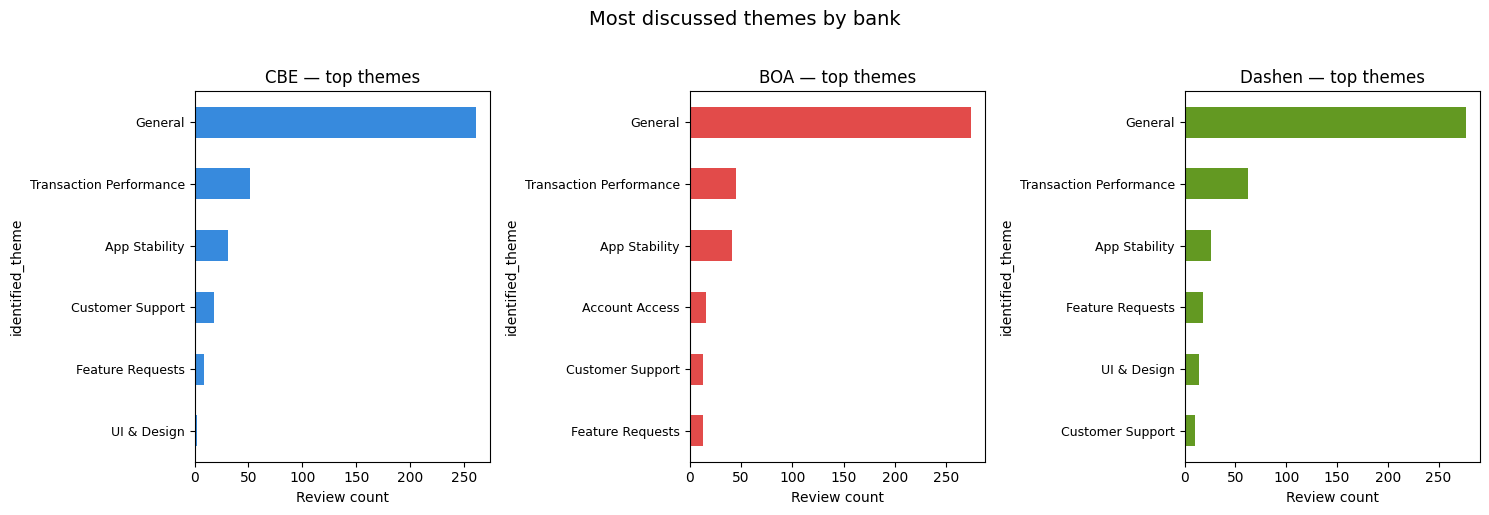

Saved → plots/themes_by_bank.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {"CBE": "#378ADD", "BOA": "#E24B4A", "Dashen": "#639922"}

for ax, bank in zip(axes, ["CBE", "BOA", "Dashen"]):
    theme_counts = (
        df[df["bank"] == bank]["identified_theme"]
        .value_counts()
        .head(6)
    )
    theme_counts.plot(kind="barh", ax=ax, color=colors[bank])
    ax.set_title(f"{bank} — top themes", fontsize=12)
    ax.set_xlabel("Review count", fontsize=10)
    ax.invert_yaxis()
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Most discussed themes by bank", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/themes_by_bank.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/themes_by_bank.png")

## 9. Visualization 4 — Sentiment by Theme (All Banks)

Which themes drive the most negative sentiment?
This tells the client exactly where to focus product investment.

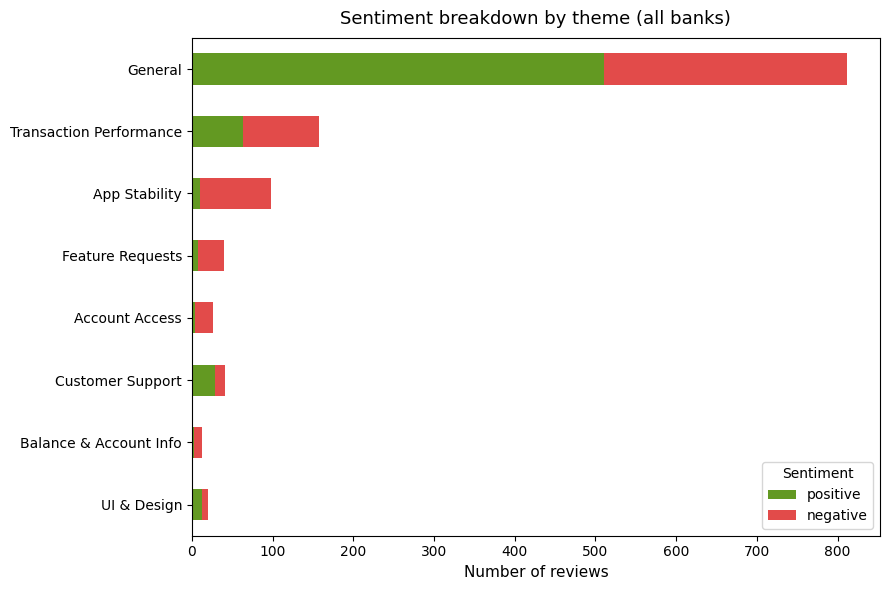

Saved → plots/sentiment_by_theme.png


In [11]:
theme_sentiment = (
    df.groupby(["identified_theme", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)

# Sort by negative count descending so the worst themes appear first
if "negative" in theme_sentiment.columns:
    theme_sentiment = theme_sentiment.sort_values("negative", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
theme_sentiment[["positive", "negative"]].plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color={"positive": "#639922", "negative": "#E24B4A"},
)
ax.set_title("Sentiment breakdown by theme (all banks)", fontsize=13, pad=10)
ax.set_xlabel("Number of reviews", fontsize=11)
ax.set_ylabel("")
ax.legend(title="Sentiment", fontsize=10)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/sentiment_by_theme.png", dpi=150)
plt.show()
print("Saved → plots/sentiment_by_theme.png")

## 10. Save Analyzed Dataset

Save the enriched DataFrame with all new columns for use in Task 3 (PostgreSQL).

In [12]:
final_cols = [
    "review", "rating", "date", "bank", "source",
    "sentiment_label", "sentiment_score", "identified_theme"
]

df[final_cols].to_csv(OUTPUT_PATH, index=False)

print(f"Analyzed dataset saved → {OUTPUT_PATH}")
print(f"Columns : {final_cols}")
print(f"Shape   : {df[final_cols].shape}")

Analyzed dataset saved → ../data/raw/reviews_analyzed.csv
Columns : ['review', 'rating', 'date', 'bank', 'source', 'sentiment_label', 'sentiment_score', 'identified_theme']
Shape   : (1208, 8)


## 11. Task 2 Summary

Document your key findings here. Replace the examples with your real numbers
after running the notebook.

---

### Sentiment findings
| Bank | Positive | Negative | Avg Score |
|------|----------|----------|-----------|
| CBE  | __%      | __%      | ___       |
| BOA  | __%      | __%      | ___       |
| Dashen | __%    | __%      | ___       |

### Top theme per bank
| Bank | #1 Theme | #2 Theme | Biggest pain point |
|------|----------|----------|--------------------|
| CBE  | ___      | ___      | ___                |
| BOA  | ___      | ___      | ___                |
| Dashen | ___    | ___      | ___                |

### Key insight for report
> _Write 2–3 sentences here summarizing what the data tells you about 
> which bank has the worst user experience and why._
